# Carga de librerías

In [168]:
# manejo de datos
from numpy import loadtxt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import multiprocessing

# Carga de los datos a un objeto de tipo DataFrame

In [169]:
# base de datos de ejemplo de arrestos en USA
datos = pd.read_csv('/content/USArrests.csv')
datos.index = datos.rownames[:]
del datos["rownames"]

In [170]:
datos.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [171]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


In [172]:
datos.head(15)

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9


# Exploración inicial de los datos

In [173]:
#medias
datos.mean()

,0
Murder,7.788
Assault,170.760
UrbanPop,65.540
Rape,21.232


In [174]:
#varianzas
datos.var()

,0
Murder,18.970465
Assault,6945.165714
UrbanPop,209.518776
Rape,87.729159


# Creación del modelo PCA

In [175]:
# se deben estandarizar las variables para que tengan media 0 y varianza 1
# por eso se utiliza StandardScaler y se utiliza
pca_pipe = make_pipeline(StandardScaler(), PCA())

# posterior a la definición del pipe de escalado y método PCA, ajustamos el modelo
pca_pipe.fit(datos)

# ahora extraemos el modelo PCA del pipe
modelo_pca = pca_pipe.named_steps['pca']

In [176]:
# valor de los loadings que definen cada componente
pd.DataFrame(modelo_pca.components_)

,0,1,2,3
0,0.535899,0.583184,0.278191,0.543432
1,-0.418181,-0.187986,0.872806,0.167319
2,-0.341233,-0.268148,-0.378016,0.817778
3,-0.649228,0.743407,-0.133878,-0.089024


In [177]:
# presentando los compontenes de forma más clara
pd.DataFrame(
    data    = modelo_pca.components_,
    columns = datos.columns,
    index   = ['PC1', 'PC2', 'PC3', 'PC4']
)

,Murder,Assault,UrbanPop,Rape
PC1,0.535899,0.583184,0.278191,0.543432
PC2,-0.418181,-0.187986,0.872806,0.167319
PC3,-0.341233,-0.268148,-0.378016,0.817778
PC4,-0.649228,0.743407,-0.133878,-0.089024


# Varianza Explicada y la Proporción de Varianza Acumulada

In [178]:
# el modelo contiene también la varianza explicada por cada componente
modelo_pca.explained_variance_ratio_

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

In [179]:
# para obtener la proporción de varianza acumulada, utilizamos el siguiente atributo
modelo_pca.explained_variance_ratio_.cumsum()

array([0.62006039, 0.86750168, 0.95664248, 1.        ])

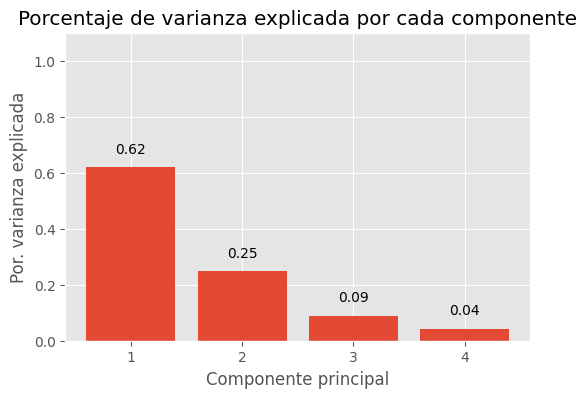

In [180]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.bar(
    x      = np.arange(modelo_pca.n_components_) + 1,
    height = modelo_pca.explained_variance_ratio_
)

for x, y in zip(np.arange(len(datos.columns)) + 1, modelo_pca.explained_variance_ratio_):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');

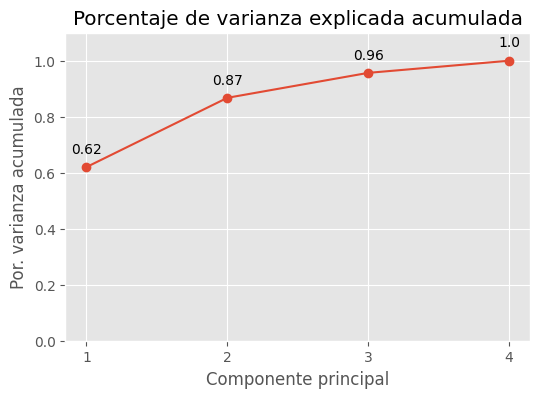

In [181]:
prop_varianza_acum = modelo_pca.explained_variance_ratio_.cumsum()
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(
    np.arange(len(datos.columns)) + 1,
    prop_varianza_acum,
    marker = 'o'
)

for x, y in zip(np.arange(len(datos.columns)) + 1, prop_varianza_acum):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')

ax.set_ylabel('Por. varianza acumulada');

# Transformando el set de datos ha su equivalente en componentes principales

In [182]:
# para transformar los datos, utilizamos el pca_pipe.transform
datos_transformados = pca_pipe.transform(X=datos)
datos_transformados = pd.DataFrame(
    datos_transformados,
    columns = ['PC1', 'PC2', 'PC3', 'PC4'],
    index   = datos.index
)
datos_transformados.head(15)

,PC1,PC2,PC3,PC4
rownames,,,,
Alabama,0.985566,-1.133392,-0.444269,-0.156267
Alaska,1.950138,-1.073213,2.040003,0.438583
Arizona,1.763164,0.745957,0.054781,0.834653
Arkansas,-0.141420,-1.119797,0.114574,0.182811
California,2.523980,1.542934,0.598557,0.341996
Colorado,1.514563,0.987555,1.095007,-0.001465
Connecticut,-1.358647,1.088928,-0.643258,0.118469
Delaware,0.047709,0.325359,-0.718633,0.881978
Florida,3.013042,-0.039229,-0.576829,0.096285


# Regresión lineal con PCA

## Preparación de datos

In [183]:
# carga de datos:
datos = pd.read_csv("/content/meatspec.csv")

In [184]:
# vemos los primeros datos para observar como está el dataset
datos.head()

,Unnamed: 0,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V92,V93,V94,V95,V96,V97,V98,V99,V100,fat
0,1,2.61776,2.61814,2.61859,2.61912,2.61981,2.62071,2.62186,2.62334,2.62511,...,2.98145,2.96072,2.94013,2.91978,2.89966,2.87964,2.85960,2.83940,2.81920,22.5
1,2,2.83454,2.83871,2.84283,2.84705,2.85138,2.85587,2.86060,2.86566,2.87093,...,3.29186,3.27921,3.26655,3.25369,3.24045,3.22659,3.21181,3.19600,3.17942,40.1
2,3,2.58284,2.58458,2.58629,2.58808,2.58996,2.59192,2.59401,2.59627,2.59873,...,2.68951,2.67009,2.65112,2.63262,2.61461,2.59718,2.58034,2.56404,2.54816,8.4
3,4,2.82286,2.82460,2.82630,2.82814,2.83001,2.83192,2.83392,2.83606,2.83842,...,2.97367,2.94951,2.92576,2.90251,2.87988,2.85794,2.83672,2.81617,2.79622,5.9
4,5,2.78813,2.78989,2.79167,2.79350,2.79538,2.79746,2.79984,2.80254,2.80553,...,3.30025,3.27907,3.25831,3.23784,3.21765,3.19766,3.17770,3.15770,3.13753,25.5


In [185]:
# eliminamos la primer columna y extraemos las variables X y Y

# para X extraemos todas las caracteristicas con excepción de la primer columna y fat
X = datos.drop(columns=[datos.columns[0], 'fat'])
# la variable objetivo es la cantidad de grasa
y = datos['fat']

In [186]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100
0,2.61776,2.61814,2.61859,2.61912,2.61981,2.62071,2.62186,2.62334,2.62511,2.62722,...,3.00247,2.98145,2.96072,2.94013,2.91978,2.89966,2.87964,2.85960,2.83940,2.81920
1,2.83454,2.83871,2.84283,2.84705,2.85138,2.85587,2.86060,2.86566,2.87093,2.87661,...,3.30473,3.29186,3.27921,3.26655,3.25369,3.24045,3.22659,3.21181,3.19600,3.17942
2,2.58284,2.58458,2.58629,2.58808,2.58996,2.59192,2.59401,2.59627,2.59873,2.60131,...,2.70934,2.68951,2.67009,2.65112,2.63262,2.61461,2.59718,2.58034,2.56404,2.54816
3,2.82286,2.82460,2.82630,2.82814,2.83001,2.83192,2.83392,2.83606,2.83842,2.84097,...,2.99820,2.97367,2.94951,2.92576,2.90251,2.87988,2.85794,2.83672,2.81617,2.79622
4,2.78813,2.78989,2.79167,2.79350,2.79538,2.79746,2.79984,2.80254,2.80553,2.80890,...,3.32201,3.30025,3.27907,3.25831,3.23784,3.21765,3.19766,3.17770,3.15770,3.13753


In [187]:
y.head()

,fat
0,22.5
1,40.1
2,8.4
3,5.9
4,25.5


In [188]:
X.shape

(215, 100)

In [189]:
y

,fat
0,22.5
1,40.1
2,8.4
3,5.9
4,25.5
...,...
210,31.3
211,33.8
212,35.5
213,42.5


In [190]:
# separamos los datos de prueba y de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.7,
                                        random_state = 2687,
                                        shuffle      = True
                                    )

# por último, normalizamos los datos
st_model = StandardScaler()
X_train = st_model.fit_transform(X_train)
X_test = st_model.fit_transform(X_test)

In [191]:
X_train

array([[-0.46657285, -0.46406459, -0.46142839, ..., -0.71310018,
        -0.71602071, -0.71831008],
       [-0.52335051, -0.52018092, -0.51705841, ..., -0.64586225,
        -0.64421038, -0.64227733],
       [ 0.31666269,  0.3133174 ,  0.31035536, ...,  0.79987817,
         0.79568886,  0.78852845],
       ...,
       [ 0.89639837,  0.89774916,  0.899134  , ...,  1.01609223,
         1.0159809 ,  1.01440769],
       [ 0.82506305,  0.82597246,  0.82675427, ...,  0.62687363,
         0.62210899,  0.6177269 ],
       [-1.00397677, -1.01720337, -1.02995285, ..., -0.99807086,
        -0.99623119, -0.99426376]])

In [192]:
pca_pipe = make_pipeline(PCA())

# posterior a la definición del pipe de escalado y método PCA, ajustamos el modelo
pca_pipe.fit(X_train)

# ahora extraemos el modelo PCA del pipe
modelo_pca = pca_pipe.named_steps['pca']

#pd.DataFrame(modelo_pca.explained_variance_ratio_.cumsum())

## Entrenamiento de un modelo lineal simple

In [193]:
modelo = LinearRegression()

# luego procedemos a entrenar el modelo
modelo.fit(X = X_train, y = y_train)

LinearRegression()

In [194]:
y_hat = modelo.predict(X = X_test).flatten()

mse = mean_squared_error(
            y_true  = y_test,
            y_pred  = y_hat
           )
rmse_rs = np.sqrt(mse)

print(f"RMSE para el conjunto de pruebas: {rmse_rs}")

RMSE para el conjunto de pruebas: 5.111429180904839


In [195]:
modelo.score(X_test, y_test)

0.8588012965723221

##

## Entrenamiento de un modelo con PCA - Todos los parámetros

In [196]:
# construimos un pipe para evaluar el modelo con todos los componentes principales
# en este caso,  ya no utilizo el escalado porque los datos fueron escalados desde la preparación
pipe_modelado = make_pipeline(PCA(), LinearRegression())
pipe_modelado.fit(X=X_train, y=y_train)

Pipeline(steps=[('pca', PCA()), ('linearregression', LinearRegression())])

In [197]:
# realizamos la predicción para los valores de prueba
y_hat = pipe_modelado.predict(X = X_test).flatten()

mse = mean_squared_error(
            y_true  = y_test,
            y_pred  = y_hat
           )
rmse_rs = np.sqrt(mse)
print(f"RMSE para el conjunto de pruebas: {rmse_rs}")

RMSE para el conjunto de pruebas: 5.111429180785236


## Entrenamiento de un modelo con PCR - Con un subconjunto de los componentes principales

In [198]:
# entrenamiento de un modelo con los primeros 30 componentes principales
pipe_modelado = make_pipeline(PCA(n_components=30), LinearRegression())
pipe_modelado.fit(X=X_train, y=y_train)

Pipeline(steps=[('pca', PCA(n_components=30)),
                ('linearregression', LinearRegression())])

In [199]:
y_hat = pipe_modelado.predict(X = X_test).flatten()

mse = mean_squared_error(
            y_true  = y_test,
            y_pred  = y_hat
           )
rmse_rs = np.sqrt(mse)
print(f"RMSE para el conjunto de pruebas: {rmse_rs}")

RMSE para el conjunto de pruebas: 4.746529863986296
